In [25]:
import config 
import numpy as np 
from utils.optuna import load_optuna_best_results
from utils.dataset import load_dataset 
from utils.plots import tm_class_sums_to_prob
import os
from itertools import combinations
from sklearn.metrics import roc_auc_score, confusion_matrix
from scipy.special import softmax
import matplotlib.pyplot as plt
import seaborn as sns

In [26]:
CURRENT_DATASET = config.BLOODMNIST


In [27]:
_, _, _, _, _, Y_test = load_dataset(config)
Y_test  = Y_test.reshape(Y_test.shape[0])

In [28]:
def load_scores(results_dir, dataset_name, specialist_name, n_epochs, num_clauses, T_best, s_best, patch_best, maxlit_best, weighted_best):
    file_path = (
        f"{results_dir}/"
        f"{specialist_name}_{n_epochs}_"
        f"{num_clauses}_"
        f"{T_best}_"
        f"{s_best:.1f}_"
        f"{patch_best}_"
        f"{maxlit_best}_"
        f"{weighted_best}.txt"
    )
    return np.loadtxt(file_path, delimiter=",")

In [29]:
best_value, best_params = load_optuna_best_results("hyperparameters/canny_edge.json")
s_best_canny = best_params["s"]
T_best_canny = best_params["T"]
patch_best_canny = best_params["patch_size"]
weighted_best = 1
maxlit_best_canny = best_params["max_included_literals"]

In [30]:
best_value, best_params = load_optuna_best_results("hyperparameters/adaptive_gaussian.json")
s_best_adaptive_gaussian = best_params["s"]
T_best_adaptive_gaussian = best_params["T"]
patch_best_adaptive_gaussian = best_params["patch_size"]
weighted_best = 1
maxlit_best_adaptive_gaussian = best_params["max_included_literals"]




In [31]:
best_value, best_params = load_optuna_best_results("hyperparameters/adaptive_mean.json")
s_best_adaptive_mean = best_params["s"]
T_best_adaptive_mean = best_params["T"]
patch_best_adaptive_mean = best_params["patch_size"]
weighted_best = 1
maxlit_best_adaptive_mean = best_params["max_included_literals"]

In [32]:
best_value, best_params = load_optuna_best_results("hyperparameters/otsu.json")
s_best_otsu = best_params["s"]
T_best_otsu = best_params["T"]
patch_best_otsu = best_params["patch_size"]
weighted_best = 1
maxlit_best_otsu = best_params["max_included_literals"]

In [33]:
best_value, best_params = load_optuna_best_results("hyperparameters/color_thermometers.json")
s_best_thermometer = best_params["s"]
T_best_thermometer = best_params["T"]
patch_best_thermometer = best_params["patch_size"]
weighted_best = 1
maxlit_best_thermometer = best_params["max_included_literals"]

The number of classes is: 8

=== Epoch 1 ===
Team Accuracy: 82.67%
Team AUC     : 0.9028

=== Epoch 2 ===
Team Accuracy: 85.62%
Team AUC     : 0.9188

=== Epoch 3 ===
Team Accuracy: 85.12%
Team AUC     : 0.9192

=== Epoch 4 ===
Team Accuracy: 87.23%
Team AUC     : 0.9268

=== Epoch 5 ===
Team Accuracy: 88.69%
Team AUC     : 0.9358

=== Epoch 6 ===
Team Accuracy: 88.37%
Team AUC     : 0.9323

=== Epoch 7 ===
Team Accuracy: 88.66%
Team AUC     : 0.9361

=== Epoch 8 ===
Team Accuracy: 89.42%
Team AUC     : 0.9396

=== Epoch 9 ===
Team Accuracy: 89.45%
Team AUC     : 0.9410

=== Epoch 10 ===
Team Accuracy: 90.00%
Team AUC     : 0.9421

=== Epoch 11 ===
Team Accuracy: 89.59%
Team AUC     : 0.9413

=== Epoch 12 ===
Team Accuracy: 90.38%
Team AUC     : 0.9438

=== Epoch 13 ===
Team Accuracy: 90.53%
Team AUC     : 0.9446

=== Epoch 14 ===
Team Accuracy: 90.56%
Team AUC     : 0.9466

=== Epoch 15 ===
Team Accuracy: 90.62%
Team AUC     : 0.9457

=== Epoch 16 ===
Team Accuracy: 91.26%
Team AUC   

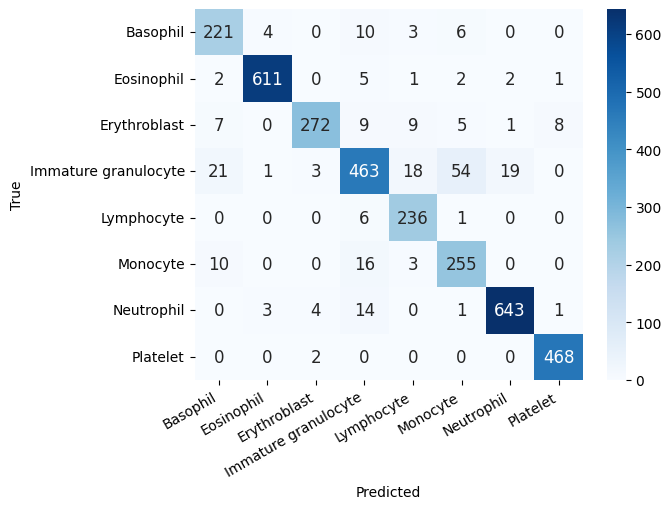

Saved: composite_plots/all_specialists_combined_confusion_matrix_epoch100_acc92.63_auc0.9576.svg


In [34]:
from scipy.special import softmax
from sklearn.metrics import roc_auc_score

if isinstance(config.labels, dict):
    labels = list(config.labels.values())
n_classes = len(labels)
print("The number of classes is:", n_classes)

for epoch in range(1, config.N_EPOCHS + 1):
    print(f"\n=== Epoch {epoch} ===")
    canny_edge_scores = load_scores(
        results_dir=config.SAVE_DIR_SCORES,
        dataset_name=CURRENT_DATASET,
        specialist_name="BloodMNIST_Canny",
        n_epochs=epoch,
        num_clauses=config.NUM_CLAUSES,
        T_best=T_best_canny,
        s_best=s_best_canny,
        patch_best=patch_best_canny,
        maxlit_best=maxlit_best_canny,
        weighted_best=weighted_best
    )
    adaptive_gaussian_scores = load_scores(
        results_dir=config.SAVE_DIR_SCORES,
        dataset_name=CURRENT_DATASET,
        specialist_name="BloodMNIST_Adaptive_Gaussian",
        n_epochs=epoch,
        num_clauses=config.NUM_CLAUSES,
        T_best=T_best_adaptive_gaussian,
        s_best=s_best_adaptive_gaussian,
        patch_best=patch_best_adaptive_gaussian,
        maxlit_best=maxlit_best_adaptive_gaussian,
        weighted_best=weighted_best
    )
    adaptive_mean_scores = load_scores(
        results_dir=config.SAVE_DIR_SCORES,
        dataset_name=CURRENT_DATASET,
        specialist_name="BloodMNIST_Adaptive_Mean",
        n_epochs=epoch,
        num_clauses=config.NUM_CLAUSES,
        T_best=T_best_adaptive_mean,
        s_best=s_best_adaptive_mean,
        patch_best=patch_best_adaptive_mean,
        maxlit_best=maxlit_best_adaptive_mean,
        weighted_best=weighted_best
    )
    otsu_scores = load_scores(
        results_dir=config.SAVE_DIR_SCORES,
        dataset_name=CURRENT_DATASET,
        specialist_name="BloodMNIST_Otsu",
        n_epochs=epoch,
        num_clauses=config.NUM_CLAUSES,
        T_best=T_best_otsu,
        s_best=s_best_otsu,
        patch_best=patch_best_otsu,
        maxlit_best=maxlit_best_otsu,
        weighted_best=weighted_best
    )
    color_thermometer_scores = load_scores(
        results_dir=config.SAVE_DIR_SCORES,
        dataset_name=CURRENT_DATASET,
        specialist_name="BloodMNIST_Color_Thermometers",
        n_epochs=epoch,
        num_clauses=config.NUM_CLAUSES,
        T_best=T_best_thermometer,
        s_best=s_best_thermometer,
        patch_best=patch_best_thermometer,
        maxlit_best=maxlit_best_thermometer,
        weighted_best=weighted_best
    )

    votes = (
        canny_edge_scores +
        adaptive_gaussian_scores +
        adaptive_mean_scores +
        otsu_scores +
        color_thermometer_scores
    )
    Y_test_predicted = votes.argmax(axis=1)
    accuracy = 100.0 * (Y_test_predicted == Y_test).mean()
    votes_prob = softmax(votes, axis=1)
    auc = roc_auc_score(Y_test, votes_prob, multi_class="ovr", average="macro")

    print(f"Team Accuracy: {accuracy:.2f}%")
    print(f"Team AUC     : {auc:.4f}")
    if epoch == config.N_EPOCHS:
        cm = confusion_matrix(Y_test, Y_test_predicted)
        fig, ax = plt.subplots(figsize=(7, 5.2))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                    xticklabels=labels, yticklabels=labels,
                    annot_kws={"size": 12})
        ax.set_xlabel("Predicted")
        ax.set_ylabel("True")
        ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")
        plt.tight_layout()

        composite_dir = "composite_plots"
        os.makedirs(composite_dir, exist_ok=True)
        filename = f"all_specialists_combined_confusion_matrix_epoch{epoch}_acc{accuracy:.2f}_auc{auc:.4f}.svg"
        save_path = os.path.join(composite_dir, filename)
        fig.savefig(save_path, format="svg", bbox_inches="tight")
        plt.show()
        print(f"Saved: {save_path}")


=== All Combinations (sorted by accuracy) ===
color_thermometer                                                                Accuracy: 93.77%  AUC: 0.9931
adaptive_mean + color_thermometer                                                Accuracy: 93.45%  AUC: 0.9927
adaptive_gaussian + color_thermometer                                            Accuracy: 93.42%  AUC: 0.9927
otsu + color_thermometer                                                         Accuracy: 93.31%  AUC: 0.9930
adaptive_gaussian + otsu + color_thermometer                                     Accuracy: 92.98%  AUC: 0.9929
adaptive_mean + otsu + color_thermometer                                         Accuracy: 92.87%  AUC: 0.9928
adaptive_gaussian + adaptive_mean + otsu + color_thermometer                     Accuracy: 92.75%  AUC: 0.9926
canny + adaptive_gaussian + otsu + color_thermometer                             Accuracy: 92.66%  AUC: 0.9920
adaptive_gaussian + adaptive_mean + color_thermometer            

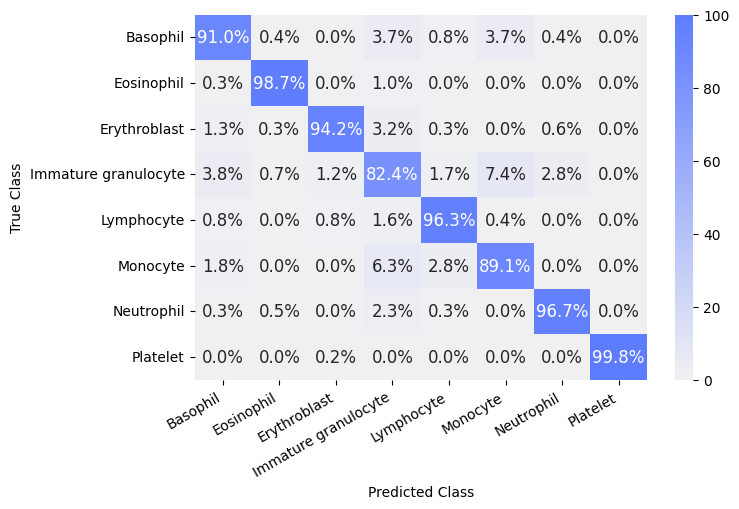

Saved: composite_plots/rank1_confusion_matrix_color_thermometer_acc93.77_auc0.9931.svg


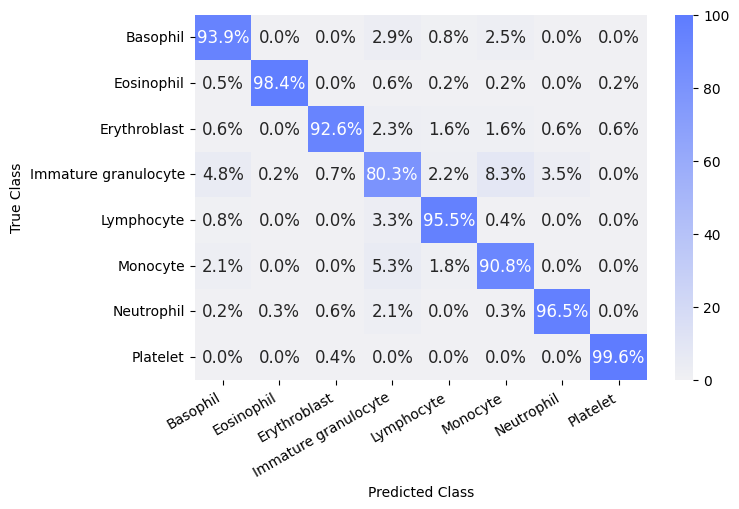

Saved: composite_plots/rank2_confusion_matrix_adaptive_mean_+_color_thermometer_acc93.45_auc0.9927.svg


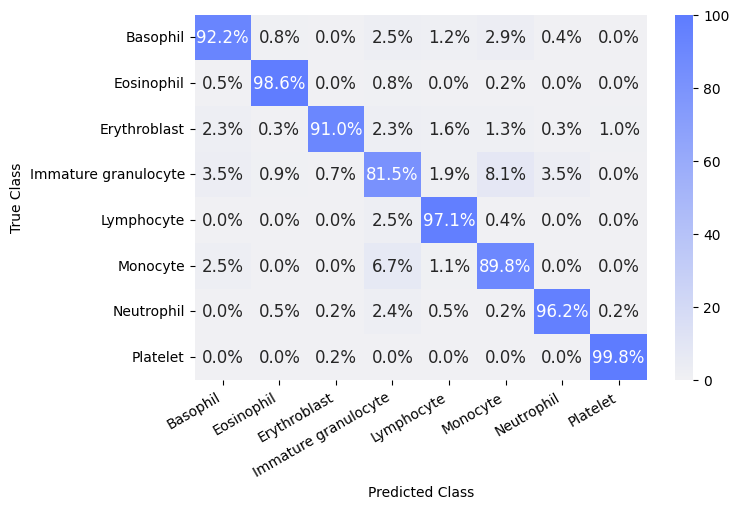

Saved: composite_plots/rank3_confusion_matrix_adaptive_gaussian_+_color_thermometer_acc93.42_auc0.9927.svg


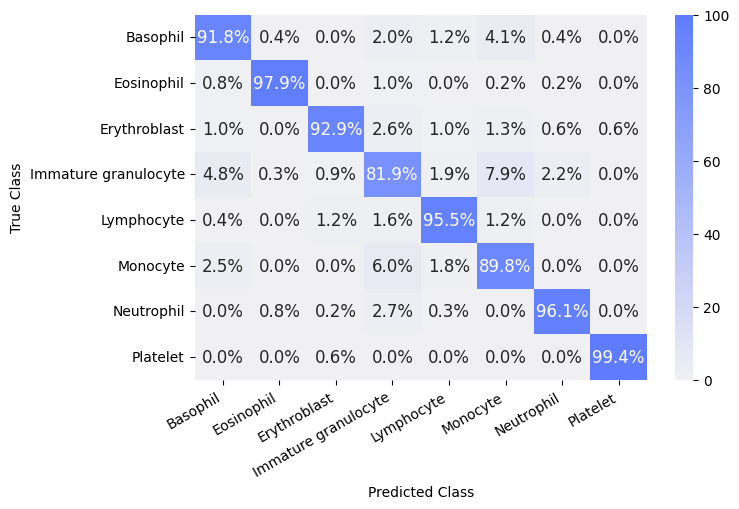

Saved: composite_plots/rank4_confusion_matrix_otsu_+_color_thermometer_acc93.31_auc0.9930.svg


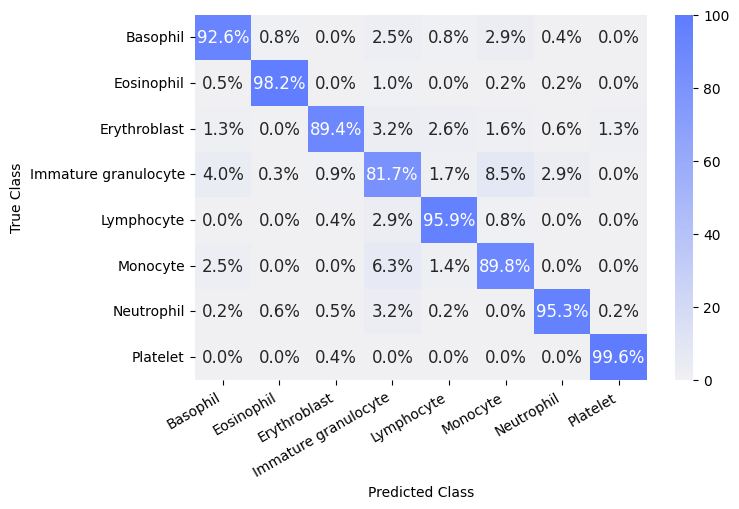

Saved: composite_plots/rank5_confusion_matrix_adaptive_gaussian_+_otsu_+_color_thermometer_acc92.98_auc0.9929.svg


In [35]:
import os
import numpy as np
from itertools import combinations
from sklearn.metrics import roc_auc_score, confusion_matrix
from scipy.special import softmax
import matplotlib.pyplot as plt
import seaborn as sns

composite_dir = "composite_plots"
os.makedirs(composite_dir, exist_ok=True)

# Composite color matching BloodMNIST theme
COMPOSITE_CMAP = sns.light_palette("#5e7cff", as_cmap=True)

specialist_names = ["canny", "adaptive_gaussian", "adaptive_mean", "otsu", "color_thermometer"]

all_scores = {
    "canny": canny_edge_scores,
    "adaptive_gaussian": adaptive_gaussian_scores,
    "adaptive_mean": adaptive_mean_scores,
    "otsu": otsu_scores,
    "color_thermometer": color_thermometer_scores,
}

alphas = {
    name: scores.max() - scores.min()
    for name, scores in all_scores.items()
}

best_accuracy = -1
best_auc = -1
best_combination = None
results = []

for r in range(1, len(specialist_names) + 1):
    for combo in combinations(specialist_names, r):
        votes = sum(all_scores[name] / alphas[name] for name in combo)
        Y_pred = votes.argmax(axis=1)
        accuracy = 100.0 * (Y_pred == Y_test).mean()
        votes_prob = softmax(votes, axis=1)
        macro_auc = roc_auc_score(Y_test, votes_prob, multi_class="ovr", average="macro")
        results.append((combo, accuracy, macro_auc))
        if accuracy > best_accuracy:
            best_accuracy = accuracy
            best_auc = macro_auc
            best_combination = combo

results.sort(key=lambda x: x[1], reverse=True)

print("\n=== All Combinations (sorted by accuracy) ===")
for combo, acc, macro_auc in results:
    print(f"{' + '.join(combo):<80} Accuracy: {acc:.2f}%  AUC: {macro_auc:.4f}")

print(f"\n=== Best Combination (by accuracy) ===")
print(f"Specialists: {' + '.join(best_combination)}")
print(f"Accuracy   : {best_accuracy:.2f}%")
print(f"AUC        : {best_auc:.4f}")

for rank, (combo, acc, macro_auc) in enumerate(results[:5], start=1):
    votes = sum(all_scores[name] / alphas[name] for name in combo)
    Y_pred = votes.argmax(axis=1)
    
    cm = confusion_matrix(Y_test, Y_pred)
    cm_percent = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
    annot = np.array([
        [f"{cm_percent[i,j]:.1f}%" for j in range(cm.shape[1])]
        for i in range(cm.shape[0])
    ])
    
    fig, ax = plt.subplots(figsize=(7.8, 5.2))
    sns.heatmap(
        cm_percent,
        annot=annot,
        fmt="",
        cmap=COMPOSITE_CMAP,
        ax=ax,
        xticklabels=labels,
        yticklabels=labels,
        annot_kws={"size": 12},
        vmin=0,
        vmax=100,
    )
    ax.set_xlabel("Predicted Class")
    ax.set_ylabel("True Class")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")
    plt.tight_layout()

    combo_str = "_+_".join(combo)
    filename = f"rank{rank}_confusion_matrix_{combo_str}_acc{acc:.2f}_auc{macro_auc:.4f}.svg"
    save_path = os.path.join(composite_dir, filename)
    fig.savefig(save_path, format="svg", bbox_inches="tight")
    plt.show()
    print(f"Saved: {save_path}")